# 수업 내용
- 1. 효율적인 Fine-tuning (PEFT)의 원리 이해
- 2. PEFT의 큰 축 - LoRA, QLoRA
- 3. Unsloth Library 소개
- 4. Unsloth Library를 사용한 추론
- 5. Unsloth Library를 사용한 Fine-tuning (QLoRA)


# 1. 효율적인 Fine-tuning (PEFT) 이란?

### Fine-tuning 개념 복습

- Fine-tuning 이라는 개념을 학습했습니다!
  - Foundation 모델에다가 추가 데이터를 넣어서 **나만의 모델을 만드는 작업** 입니다!
  - 모델을 내 필요에 맞게 추가 학습시키는 것입니다.

- Fine-tuning의 종류
  - **Full Fine-tuning**
    - 전체 Layer의 파라미터를 업데이트 합니다. 많은 비용이 들어갑니다.
    - 추가 학습이 잘 안되면, 모델 성능이 오히려 안좋아질수도 있습니다.
  - **Partial Fine-tuning**
    - 일부 Layer의 파라미터만 업데이트 합니다
    - 이전 수업에서 Linear Probing을 했습니다
      - 마지막 Layer만 파라미터 업데이트 했습니다.

  - **효율적인 파인튜닝 (PEFT)** <- **오늘 수업 내용**
    - 기존 학습된 파라미터를 거의 건드리지 않습니다.
    - 기존 파라미터가 아닌, 새로운 파라미터를 추가하여 학습합니다.

### PEFT! 효율적 파라미터 파인튜닝
- 이제는 모델의 규모가 너무 커져서, Full Fine-tuning을 하기 어렵습니다.
  - 그만한 데이터랑 GPU랑 시간이 없습니다!
- 추가 학습도 적은 비용으로 할수 있는 방법이 필요했습니다.
- 아래와 같은 방법들이 생겼습니다.
    - **LoRA** (오늘 수업할 내용)    
    - Adapter-Tuning
    - Prompt-Tuning
    - 등등

- 위 방법들을 **PEFT(Parameter-Efficient Fine-Tuning)** 라고 합니다.
  - 이름 그대로 **파인튜닝을 효율적으로 하자!** 라는 의미입니다
<br/>


### 학습 비용을 아끼는 또 하나의 방법 - 모델 크기를 줄이자!
- 모델 자체를 작게 만들면, 학습 비용도 내려갈것이 틀림이 없습니다.
  - **양자화** : 다 만들어진 모델을, 작게 축소하기 (오늘 수업할 내용)
  - Pruning : 가지치기, 불필요했던 파리미터를 찾아 제거하기
  - 등등

<br/>

- 대신 성능이 조금 낮아질 순 있습니다.
  - 성능이 아주 조금만 낮아지고, 모델 크기가 많이 줄어든다면 의미가 있습니다!

# 2. PEFT의 큰 축을 소개합니다. - LoRA
- 효율적으로~ 파인튜닝을 하기 위한 대표적인 방법이 LoRA 입니다.
  - 적은 량의 추가 학습으로 Full Fine-tuning 과 같은 효과 내기!!
  - 아이디어가 너무 좋습니다!

<br/>

- 한번 LoRA의 원리를 쉽게 이해해보겠습니다.

### LoRA 원리 이해하기 1단계 - Full Fine-tuning 생각해보기:

- Full Fine-tuning을 생각해보겠습니다.
  - 학습의 전 후 파라미터는 아래와 같이 될겁니다.
  - 파라미터 행렬이 원래 엄청 거대한 크기인데, 설명 편의상 3x3으로 표현했어요.

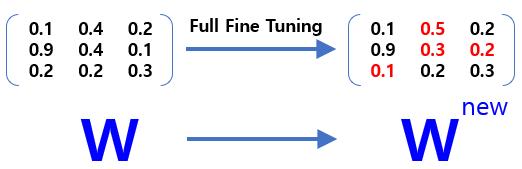

- 이걸 다음과 같이 표현할수도 있습니다.

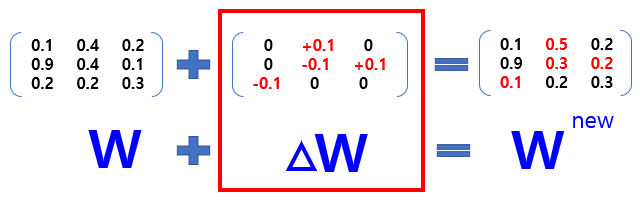

- 그럼 **Full-Fine tuning**은 결국 위에 빨간 사각형 영역의 **delta W 값(변화량)**을 알아내는 작업입니다.

### LoRA 원리 이해하기 2단계 - 선형대수학의 행렬곱

- [3 x 1] 행렬과 [1 x 3] 행렬을 곱하면 [3 x 3] 행렬이 됩니다.

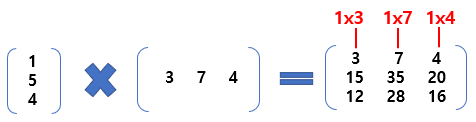

- 정리하자면 다음과 같습니다.
  - **[N x 1] 행렬과 [1 x N] 행렬의 곱으로 [N x N] 행렬을 만들 수 있다.**

### LoRA 원리 이해하기 3단계 - 행렬들의 합



- 한 행렬은 각각의 행렬들의 합으로 구성할 수 있습니다.

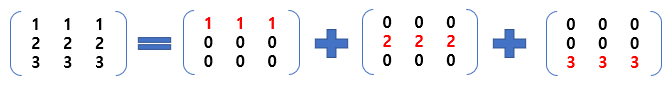

### LoRA 원리 이해하기 4단계 - delta W 구하기

- Full 파인튜닝할때 delta W를 구하는 것이죠?
- delta W는 **더 적은수의 파라미터의 연산**으로 **근사값**을 구할 수 있습니다.
  - 즉 delta W 의 모든 파라미터를 알아낼 필요가 없습니다.
  - delta W를 만들 수 있는 더 적은수의 파라미터를 알아내면 됩니다!
  - 이것이 LoRA의 원리입니다.

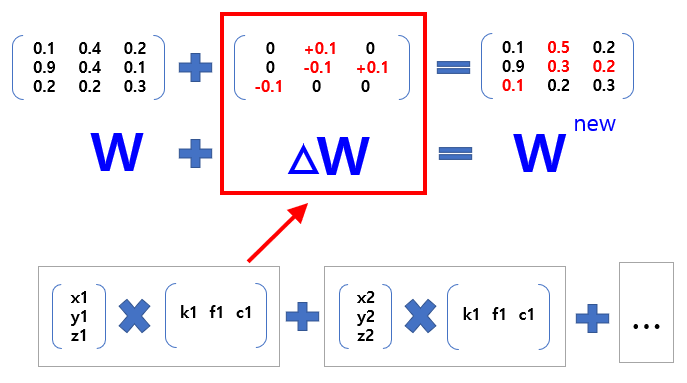

- 위 그림을보시면 delta W 를 어떻게 만들어내는지 확인할 수 있습니다.
  - [3 x 1] 행렬과 [1 x 3] 행렬의 곱을 합니다.
  - 이렇게 만들어진 **행렬을 합쳐서 실제 delta W를 근사**합니다.



- LoRA는 Full Fine-tuning 보다 알아내야할 (학습해야할) 파라미터 개수가 더 적습니다.
  - 만약 delta W 행렬이 10,000 x 10,000 사이즈라고 할 경우를 생각해보세요.
    - Full Fine tuning 에서 알아내야 할 파라미터 개수 = 1억개 입니다.
    - LoRA 로 Full Fine tuning과 비슷한 효과를 낼수 있는 파라미터 개수 = 100만개로도 가능합니다.
      - 더 많아질수록 delta W 랑 점점 더 근사한 값으로 됩니다.

<br/>

- LoRA를 쓰면, Full Fine-tuning의 delta W 값을 유사하게 만들 수 있습니다.

<br/>

- 아래 그림은 Full 파인튜닝과 LoRA와 원리를 하나의 그림으로 정리한 겁니다.
  - (a) 풀 파인튜닝
    - Inputs X : 문장, 질문, 토큰 벡터, 이미지 특징값 등 모델에 넣는 데이터 X
    - Pretrained weights W : 사전 학습된 원래 모델의 가중치
    - Weights update ΔW : 풀 파인튜닝하면서 바뀌는 값 (NxM 큰 행렬)
    - Outputs : 최종 출력 = 원래 가중치 W의 영향 + 바뀐 부분 ΔW의 영향
    - N x M : W와 같은 크기의 ΔW 행렬
  <br/>
  
  - (b) LoRA
    - Pretrained weights W: 사전 학습된 원래 모델의 가중치 고정(freeze)
    - A, B는 설명에서 [3 x 1], [1 x 3] 행렬을 의미합니다.
    - A : 넓은 입력을 좁은 차원으로 줄이는 LoRA 모듈
    - B : 좁은 차원을 다시 넓은 차원으로 펼쳐 보정값을 만드는LoRA 모듈
    - K : 얼마나 작게 줄일 것인지 정하는 차원 크기(LoRA의 압축 정도)
    - Outputs : 최종 출력 = 원래 출력 + LoRA 보정 출력
    

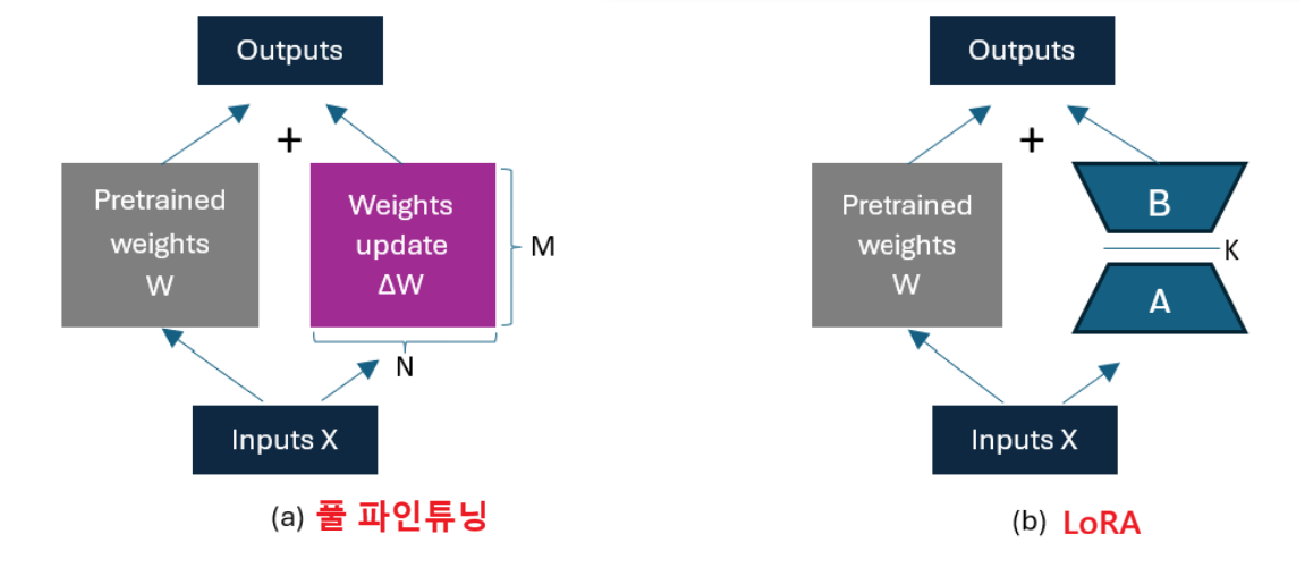

# 3. QLoRA 이해하기

### QLoRA 이해하기 1 단계 - 양자화 이해하기

- 5자리수의 곱을 계산하는 것 보다는.. 2자리 곱을 계산하는게 훨씬 빠를겁니다.
  - 연산속도도 그렇고, 저장 공간도 그렇구요.
- AI 연산들은 기본적으로 16 bit 로 소수점(실수)를 표현하고, 계산합니다.
- 양자화란 16 bit보다 더 작은 bit를 사용해서 연산하고, 값을 저장하는 것을 뜻합니다.

<br/>


- 0.0 ~ 1.0 범위를 균등하게 나누어 표현하는 경우..<br/>
bit 수에 따른 실수 표현 step은 다음과 같을 수 있습니다. <br/>
(실제로 AI에서는 BF16, FP16 등으로 아래와 같은 균등분할 방법을 쓰지 않지만, bit에 따른 정밀도 설명을 위함입니다.)
  
  - 2 bit : 0.3333
  - 3 bit : 0.1429
  - 4 bit : 0.0667
  - 5 bit : 0.03226
  - 8 bit : 0.00392
  - 16 bit : 0.00001526

<br/>

- 위 경우 2 bit로는 실수를 이렇게 밖에 표현 못합니다.
  - 0.3333 / 0.6666 / 0.9999 끝
  - 표현 범위가 작습니다.

<br/>

- 그래서 16 bit로 저장된 값들을 4 bit 근사치로 바꾸면, 성능이 낮아지겠죠?
  - 대신 4 bit 실수를 취급하는 모델로 변경하면, 추론 속도, 파인튜닝 속도 등이 빨라질겁니다.
  - 모든 파라미터를 4 bit로 바꾸는 건 아니고, 연산에 중요한 부분은 16 bit 그대로 사용합니다.

### QLoRA 이해하기 2 단계 - QLoRA 란?

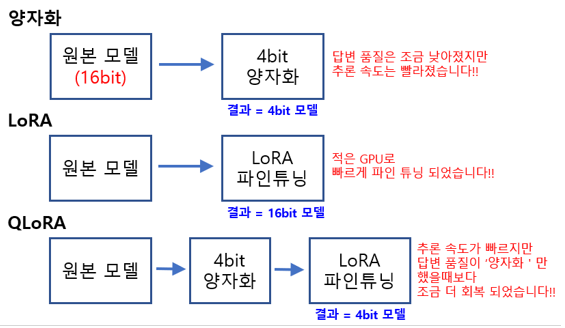

- QLoRA의 개념은 간단합니다!
  - **Quantized Low-Rank Adaptation : 양자화된 모델에 LoRA 적용**
  - 16 bit로 된 모델을 4 bit로 양자화 합니다.
    - 속도는 개선되었지만, 성능이 조금 떨어집니다.
  - 여기서 4bit 양자화 된 모델을 기반으로 만든 LoRA를 추가합니다.(파인튜닝)
    - 속도는 여전히 빠르며, 성능이 많이 회복됩니다.

### [중요] LoRA 가 가진 의미
- LoRA는 대형 모델.. Foundation Model의 파인튜닝을 **대중화** 시켰습니다.
- 집에서 사용하는 PC용 그래픽카드로도 Foundation Model 학습이 가능해졌습니다.

# 4. Unsloth Library 소개

- Unsloth Library는 저성능, 적은 개수의 GPU로 파인튜닝을 가능하도록 만든 Library 입니다.
  - 허깅페이스 Transformer Library 처럼 추론도 가능합니다.
  - 허깅페이스 Transformer Library 쓰는 것 보다 LoRA 학습 효율이 더 좋다고 합니다.
    - 참고: https://unsloth.ai/docs (공식홈페이지 설명에 따르면)
    - **2배 이상 학습속도가 빠름**
    - **70% 이상 GPU 메모리 사용량이 줄어듬**
  - 비교 대상은 허깅페이스의 Flash Attention 2 가속화 옵션 대비입니다.
    - 그런데 구글 코랩의 T4 GPU에서는 Flash Attention 2 가속화 옵션도 사용못합니다. (유료 GPU만 사용 가능)
    - 그래서 코랩 사용자한테는 Unsloth의 의미가 더더욱 크답니다.
  
<br/>

- 앞으로 파인튜닝은 QLoRA를 하고, Unsloth Library로 합시다!!

# 5. Unsloth로 추론하기
- Unsloth로 모델을 추론해보며, Unsloth Library에 친숙해집시다.

### 추론에 사용할 모델 소개 : Gemma3n

- 추론에 사용할 모델은 Google의 초 경량 **멀티모달 모델**인 Gemma3n (잼마3n) 입니다.
  - 2025년 6월에 출시된 임베디드용 경량 모델입니다.
    - 텍스트, 이미지, 오디오, 동영상 입력 됩니다.
    - 참고 : https://developers.googleblog.com/ko/introducing-gemma-3n/

  - 두 가지 모델을 제공합니다.
    - E2B : 2B 수준으로 동작 가능한 모델입니다. **속도**를 중요시합니다.
    - E4B : 4B 수준으로 동작 가능한 모델입니다. **성능**을 중요시합니다.

  - 모델 시연 영상한번 보고 하시죠.
    - 아래 유튜브 링크를 누르시면 2:10 초 부분인 시연 영상이 Play 됩니다.
    - https://youtu.be/eJFJRyXEHZ0?t=128


### 설치하기
- 해당 내용은 Unsloth 공식 Document 내용을 참고하였습니다.
- https://unsloth.ai/docs/get-started/install/pip-install

In [1]:
# Colab에서는 진행하지 말것!!!
!curl -fsSL https://unsloth.ai/install.sh | sh


  🦥 Unsloth Studio Installer
  ────────────────────────────────────────────────────

  platform       wsl

  deps           missing: libcurl4-openssl-dev
                 These are needed to build the GGUF inference engine.

                 installing uv package manager...
  venv           creating Python 3.13 virtual environment
                 /root/.unsloth/studio/unsloth_studio
  venv           using environment
                 /root/.unsloth/studio/unsloth_studio
                 installing PyTorch (https://download.pytorch.org/whl/cu130)...
                 installing unsloth (this may take a few minutes)...
  setup          running unsloth studio update...

  🦥 Unsloth Studio Setup
  ────────────────────────────────────────────────────
  frontend       up to date
  deps           [====================] 10/10  finalizing          
  deps           installed
  transformers   5.x pre-installed
                 resolved llama.cpp tag: b8508
                 installing prebuilt l

In [2]:
%%capture
# Colab에서는 진행하지 말것!!!
!pip install --no-deps --upgrade timm # Only for Gemma 3N

In [3]:
%%capture
# Colab에서 설치 진행
!pip install unsloth

### 모델 로딩 (with 다운로드)
- FastModel 이라는 클래스를 사용합니다.
- 모델 로딩, 추론, 파인튜닝을 할 때 사용합니다.

<br/>

- 원래 Gemma3N의 주소는 다음과 같습니다.
  - https://huggingface.co/google/gemma-3n-E2B-it
  - 허깅페이스 KEY 를 넣어야 사용가능합니다.
- 그런데 **unsloth이 직접 업로드한 모델은 허깅페이스 KEY 없어도 됩니다.**
- 양자화된 모델도 제공합니다.
  - unsloth/gemma-3n-E4B-it : E4B는 코랩의 T4 GPU로 안돌아갑니다.
  - unsloth/gemma-3n-E2B-it : E4B보다 더 작은 경량화된 모델
  - **unsloth/gemma-3n-E2B-it-unsloth-bnb-4bit** : Unsloth에서 E2B를 4비트로 양자화한 모델 입니다.



In [1]:
# 시간이 5~7분 정도 소요됩니다.
from unsloth import FastModel
import torch

model, tokenizer = FastModel.from_pretrained(
    model_name = "unsloth/gemma-3n-E2B-it-unsloth-bnb-4bit", # 허깅페이스 모델 이름
    dtype = None, # None 을 하면 자동으로 데이터 타입을 인식합니다.
    max_seq_length = 2048, # 모델이 한번에 인식할 수 있는 최대 토큰 길이
    load_in_4bit = True,  # 4 bit 양자화 옵션 True (메모리 절약)
    full_finetuning = False, # Full Finetuning 안함
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.3.4: Fast Gemma3N patching. Transformers: 4.57.6.
   \\   /|    NVIDIA GeForce RTX 5060 Ti. Num GPUs = 1. Max memory: 15.928 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.3.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.30. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

### 추론 함수
- do_gemma_3n_inference 함수를 하나 만듭니다.

In [2]:
from transformers import TextStreamer
# Helper function for inference
def do_gemma_3n_inference(messages, max_new_tokens = 128):
    _ = model.generate(
        **tokenizer.apply_chat_template(
            messages,
            add_generation_prompt = True, # Must add for generation
            tokenize = True,
            return_dict = True,
            return_tensors = "pt",
        ).to("cuda"),
        max_new_tokens = max_new_tokens,
        temperature = 1.0, top_p = 0.95, top_k = 64,
        streamer = TextStreamer(tokenizer, skip_prompt = True),
    )

### 이미지 추론하기

- 아래 이미지와 함께 Text를 주고 추론을 시켜봅니다.
  - 이 동물은 어떤 영화에 출현했니?

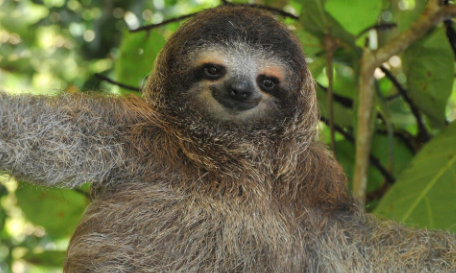

In [3]:
sloth_link = "https://files.worldwildlife.org/wwfcmsprod/images/Sloth_Sitting_iStock_3_12_2014/story_full_width/8l7pbjmj29_iStock_000011145477Large_mini__1_.jpg"

messages = [{
    "role" : "user",
    "content": [
        { "type": "image", "image" : sloth_link },
        { "type": "text",  "text" : "이 동물은 어떤 영화 나오니?" }
    ]
}]

# 처음에는 1분~3분 정도 소요될 수 있습니다.
do_gemma_3n_inference(messages, max_new_tokens = 256)

이 동물은 **바나나**라는 영화에 등장합니다. 

바나나(Banana)는 2019년에 개봉한 코미디 영화로, 슬로스의 귀여운 모습과 함께 다양한 에피소드를 담고 있습니다. 

혹시 다른 영화에서 슬로스를 보셨거나, 슬로스에 대해 궁금한 점이 있으신가요?<end_of_turn>


### 삼행시를 시켜봅니다.

- 삼행시를 시켜봅시다.: 핫도그, 햄버거, 맥도날드, 본인이름 등

In [4]:
messages = [{
    "role": "user",
    "content": [{ "type" : "text",
                  "text" : "3행시를 지어줘, 날 웃겨야해:\n\n핫도그" }]
}]
do_gemma_3n_inference(messages)

## 핫도그 3행시

**핫**한 미소로 시작하는 하루,
**도**른독한 웃음꽃 피우며,
**그**냥 핫도그 하나에 행복 가득! 😆<end_of_turn>


# 6. Unsloth로 파인튜닝(PEFT) - 제주도 사투리 번역기 만들기

이번 실습에서는 LLM이 **표준어를 제주도 사투리로 번역**하도록 학습시켜 보겠습니다.

### 6-1. 파인튜닝에 사용할 모델 소개 : Qwen3 (멀티모달 모델 아닙니다!)

- 모델마다 한국어 파인튜닝이 잘되는 모델이 있고, 아닌 모델이 있습니다.
  - Gemma3n 실험결과, 권장 하이퍼파라미터로는 한글 파인튜닝이 잘 안되었습니다.
  - 한국어를 위한 좋은 하이퍼파라미터가 있으면 잘 될수도 있겠죠?
- 이번 시간에는 Qwen3을 이용하여 LoRA 파인튜닝을 해보겠습니다.
  - 파인튜닝을 위해, 컴퓨터 재부팅 후 다시 진행합니다.
  - Runtime을 새로 연결해주세요. 이는 컴퓨터 재부팅에 비유할수 있습니다.
  - 필요한 Library를 처음부터 다시 설치할겁니다.

### 6-1. Model 로드 / 추론해보기
- Qwen3 모델을 허깅페이스에서 다운로드 및 로드합니다.
- 4B 크기의 모델이며, 5060ti GPU에서 잘 동작될 만큼 최적화가 잘 되어있습니다.
  - 한글도 잘되고, 파인튜닝도 되게 잘되는 모델이기에, 개인 프로젝트하기에 좋습니다.

- 4 bit로 양자화된 모델을 LoRA 파인튜닝하는 것이니까, 여기서 파인튜닝하면 QLoRA가 되겠죠!?

In [9]:
# 1분 정도 소요됩니다
from unsloth import FastLanguageModel
import torch

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen3-4B-Instruct-2507",
    max_seq_length = 2048, # Choose any for long context!
    load_in_4bit = True,  # 4 bit quantization to reduce memory
    load_in_8bit = False, # A bit more accurate, uses 2x memory
    full_finetuning = False, # We have full finetuning now!
)

==((====))==  Unsloth 2026.3.4: Fast Qwen3 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA GeForce RTX 5060 Ti. Num GPUs = 1. Max memory: 15.928 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.3.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.30. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/3.55G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/237 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

unsloth/qwen3-4b-instruct-2507-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


- 모델 추론을 담당하는 함수를 하나 만듭니다.

In [11]:
from transformers import TextStreamer
# Helper function for inference
def do_qwen3_inference(messages, max_new_tokens = 128):
    _ = model.generate(
        **tokenizer.apply_chat_template(
            messages,
            add_generation_prompt = True, # Must add for generation
            tokenize = True,
            return_dict = True,
            return_tensors = "pt",
        ).to("cuda"),
        max_new_tokens = max_new_tokens,
        temperature = 0.7, top_p = 0.8, top_k = 20,
        max_length = None,
        use_cache = False,
        streamer = TextStreamer(tokenizer, skip_prompt = True),
    )

- 파인튜닝 하기 전, 제주도 사투리를 이해하는지 테스트해봅시다.
  - 잘 모르는 것 같습니다.

In [ ]:
messages = [{
    "role": "user",
    "content": "다음 문장을 제주도 사투리로 번역해줘:\n\n귤 먹으면서 바다에서 놀면 좋아요!"
}]

do_qwen3_inference(messages)

### 6-3. LoRA 어댑터 추가하기
- LoRA 어댑터를 추가합니다.
- 이 어댑터에 있는 소량의 파라미터만 학습할 예정입니다!
- 이 어댑터의 Output 은 원래 가중치(W)에 더해질 가중치 값입니다. **(delta W를 근사하는 LoRA A, B들)**

In [9]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 32, # Choose any number > 0 ! Suggested 8, 16, 32, 64, 128
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 32,
    lora_dropout = 0, # Supports any, but = 0 is optimized
    bias = "none",    # Supports any, but = "none" is optimized
    # [NEW] "unsloth" uses 30% less VRAM, fits 2x larger batch sizes!
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for very long context
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
)

Unsloth 2026.3.18 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


### 6-4. 모델의 입력 포맷 확인하기
- 모델마다 사용하는 포맷이 있습니다.
  - Qwen이 사전학습될때 사용했되었던... 모델 고유의 포맷입니다.
  - 따라서 추가 학습할때도, 이 포맷에 맞추어 데이터를 넣어줘야합니다.

- 이렇게 언어마다 사용하는 포맷을 "**chat template**" 이라고 합니다.

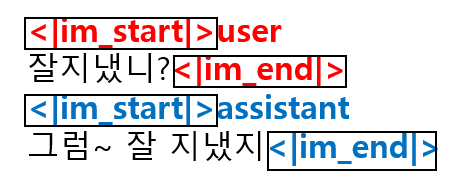

### 6-5. Dataset 준비하기
- 파인튜닝에 사용할 "제주도 사투리 번역" 데이터셋을 먼저 살펴보겠습니다
  - https://huggingface.co/datasets/junyeong-nero/jeju-dialect-to-standard
- Data Studio를 클릭하면, 데이터셋을 확인할 수 있습니다.

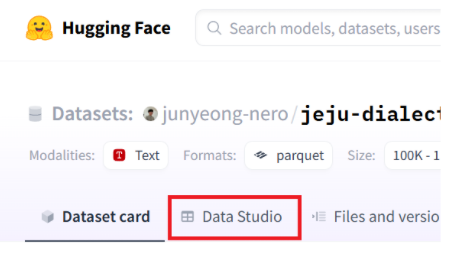

- 이 데이터셋은 2개의 컬럼으로 구성되어있습니다.
  - "standard" : 표준어
  - "dialect" : 사투리

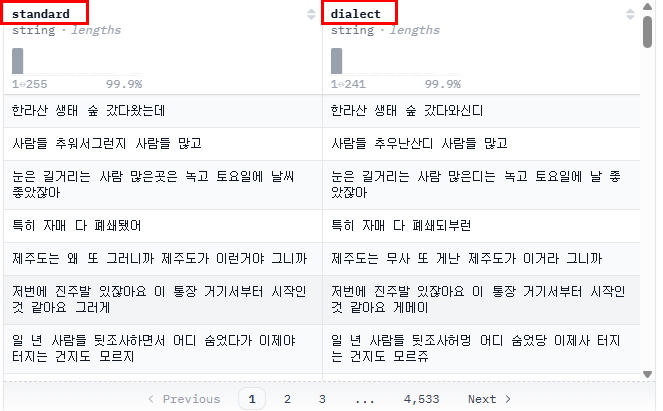

- 데이터 셋을 로드합시다.

In [10]:
from datasets import load_dataset

# 허깅페이스 허브에서 제주도 사투리 데이터셋을 불러옵니다.
# 전체 데이터(453k)는 양이 많으므로, 데모를 위해 10,000개만 사용합니다.
dataset_origin = load_dataset("junyeong-nero/jeju-dialect-to-standard" , split = "train[:10000]")

README.md:   0%|          | 0.00/572 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/35.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/453270 [00:00<?, ? examples/s]

In [11]:
print(dataset_origin[100]['standard']) # 100번째 데이터
print('-------------')
print(dataset_origin[100]['dialect'])


 미지근따뜻
-------------
 맨도롱또똣


### 6-6. Chat Template에 맞춰 포맷 변경하기
- Chat Template으로 바꾸려면 다음 순서로 바꾸는 것을 가이드하고 있습니다.
- 이는 유지보수의 편의성 위한 허깅페이스의 권장 가이드입니다!

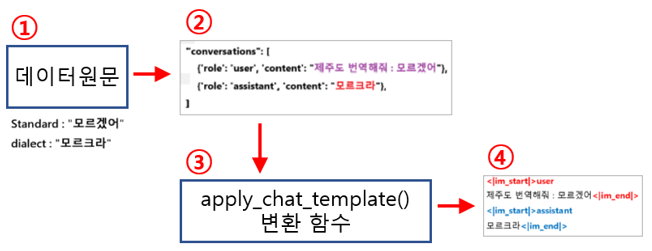

In [12]:
# 원본 데이터는 'standard', 'dialect' 컬럼으로 구성되어 있습니다.
# 이것을 Gemma의 대화 형식에 맞게 변환하는 함수를 정의합니다.
def format_jeju_data(example):
    return {
        "conversations": [
            {'role': 'user', 'content': f"다음 문장을 제주도 사투리로 번역해줘:\n\n{example['standard']}"},
            {'role': 'assistant', 'content': example['dialect']},
        ]
    }

# map 함수를 사용해 데이터셋 전체에 함수를 적용합니다.
dataset = dataset_origin.map(format_jeju_data, remove_columns=list(dataset_origin.features))

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

- 변환이 잘 되었는지 출력해봅시다.

In [13]:
dataset[100]['conversations']

[{'content': '다음 문장을 제주도 사투리로 번역해줘:\n\n 미지근따뜻', 'role': 'user'},
 {'content': ' 맨도롱또똣', 'role': 'assistant'}]

- 이제 apply_chat_template() 를 거치면, 모델이 원하는 포맷이 완성됩니다.
  - qwen3용 chat template 객체를 먼저 생성합니다.
  - 이후 apply_chat_template()을 이용하여 최종 포맷으로 변경합니다.


In [14]:
from unsloth.chat_templates import get_chat_template
tokenizer = get_chat_template(
    tokenizer,
    chat_template = "qwen3-instruct",
)

In [15]:
def formatting_prompts_func(examples):
   convos = examples["conversations"]
   texts = [tokenizer.apply_chat_template(convo, tokenize = False, add_generation_prompt = False) for convo in convos]
   return { "text" : texts, }

dataset = dataset.map(formatting_prompts_func, batched = True)

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

- 완성된 포맷을 확인해봅시다.

In [16]:
dataset[100]['text']

'<|im_start|>user\n다음 문장을 제주도 사투리로 번역해줘:\n\n 미지근따뜻<|im_end|>\n<|im_start|>assistant\n 맨도롱또똣<|im_end|>\n'

### 6-7. 모델 학습 준비
- 이제 학습을 진행할 '트레이너(Trainer)'를 설정합니다.
- 트레이너는 모델, 토크나이저, 데이터셋을 받아 학습 과정을 총괄하는 감독관과 같습니다.
  - 이곳에서 하이퍼파라미터들을 세팅합니다.

In [24]:
from trl import SFTTrainer, SFTConfig
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    eval_dataset = None, # Can set up evaluation!
    args = SFTConfig(
        dataset_text_field = "text",
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4, # Use GA to mimic batch size!
        warmup_steps = 5,
        # num_train_epochs = 1, # Set this for 1 full training run.
        max_steps = 60, # epochs 60회 학습
        learning_rate = 2e-4, # Reduce to 2e-5 for long training runs
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        report_to = "none", # Use TrackIO/WandB etc
    ),
)

Unsloth: Switching to float32 training since model cannot work with float16


Unsloth: Tokenizing ["text"] (num_proc=5):   0%|          | 0/10000 [00:00<?, ? examples/s]

### 6-8. 명령과 답변 구분해주기
- 모델은 "질문"을 생성해야 하는 것이아니라, "답변" 부분만 예측하여 문장을 생성해야합니다.
- 아래는 모델이 예측해야할 "답변" 부분이 어딘지지 알려주는 코드입니다

In [25]:
from unsloth.chat_templates import train_on_responses_only
trainer = train_on_responses_only(
    trainer,
    instruction_part = "<|im_start|>user\n",
    response_part = "<|im_start|>assistant\n",
)

Map (num_proc=5):   0%|          | 0/10000 [00:00<?, ? examples/s]

Filter (num_proc=5):   0%|          | 0/10000 [00:00<?, ? examples/s]

### 6-9. 학습 시작!
- Loss가 줄어드는 모습을 확인할 수 있습니다.
- Loss가 전반적으로 줄어들지 않으면 학습이 안되고 있는 것입니다

In [26]:
trainer_stats = trainer.train()  # 학습하는데 2~3분 소요됩니다

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 10,000 | Num Epochs = 1 | Total steps = 60
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 66,060,288 of 4,088,528,384 (1.62% trained)


Step,Training Loss
1,0.632761
2,1.435802
3,0.922408
4,0.563402
5,0.517619
6,0.465706
7,0.854720
8,1.272390
9,1.061530
10,0.637446


### 6-10. 파인튜닝된 모델 테스트하기

- 학습이 끝난 모델이 얼마나 똑똑해졌는지 테스트해볼 시간입니다.
   - 제주도 사투리를 쓰는 척 하는 서울사람이 되었습니다.

In [27]:
messages = [
    {"role" : "user", "content" : "다음 문장을 제주도 사투리로 번역해줘:\n\n 귤 먹으면서 바다에서 놀면 좋아요!"}
]
text = tokenizer.apply_chat_template(
    messages,
    tokenize = False,
    add_generation_prompt = True, # Must add for generation
)

from transformers import TextStreamer
_ = model.generate(
    **tokenizer(text, return_tensors = "pt").to("cuda"),
    max_new_tokens = 1000, # Increase for longer outputs!
    temperature = 0.7, top_p = 0.8, top_k = 20,
    max_length = None,
    use_cache = False,
    streamer = TextStreamer(tokenizer, skip_prompt=True, skip_special_tokens=True),
)

/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


 귤 먹엉중에 바당에서 놀면 좋아요!


### 6-11. 모델 저장하기

힘들게 학습시킨 모델을 저장해서 나중에 다시 사용하거나 다른 사람과 공유할 수 있습니다.

- **LoRA 어댑터만 저장 (권장)**: 가장 가볍고 효율적인 방법입니다. 나중에 베이스 모델 위에 이 어댑터를 얹어서 사용하면 됩니다.
- **모델 병합(Merge) 후 저장**: 베이스 모델과 LoRA 어댑터를 합쳐서 하나의 완전한 모델로 저장합니다. 파일 크기는 커지지만, 다른 환경에서 베이스 모델 없이 단독으로 사용하기 편리합니다.

In [28]:
# LoRA 어댑터만 저장합니다. (파일 크기가 매우 작습니다)
model.save_pretrained("gemma_jeju_lora")
tokenizer.save_pretrained("gemma_jeju_lora")

print("LoRA 어댑터가 'gemma_jeju_lora' 폴더에 저장되었습니다.")

# (선택) 모델을 병합하여 저장합니다. 시간이 조금 걸릴 수 있습니다.
if False: # 필요할 때 True로 바꿔서 실행하세요.
    merged_model = model.merge_and_unload() # 베이스 모델과 LoRA 어댑터 병합
    merged_model.save_pretrained("gemma_jeju_merged") # 병합된 모델 저장
    tokenizer.save_pretrained("gemma_jeju_merged")
    print("병합된 모델이 'gemma_jeju_merged' 폴더에 저장되었습니다.")

LoRA 어댑터가 'gemma_jeju_lora' 폴더에 저장되었습니다.


# 7. [참고] 파인튜닝 추가 샘플코드

### PEFT 샘플코드 소개
- PEFT 추가 샘플코드입니다.
  - 멀티모달 모델 qwen3-vl, 4bit 양자화 모델 입니다.
  - unsloth 공식문서 코드를 편집해서 만들었습니다.

<br/>

- 모델 설명
  - 포켓몬 이미지를 입력하면 --> 포켓몬의 이름과 속성이 출력되는 모델

### 쥬피터랩 - 커널 재시작 하기

- 이전 실습때 이미 GPU를 다 써버려서, 그대로 실습하면 GPU가 모자르다고 에러가 날수있습니다.
- 안전하게 Restart Kernel을 실행해서, 쥬피터랩이 차지하고있는 GPU를 없애줍시다.
- 그리고 Unsloth 설치부터 다시 해봅시다.

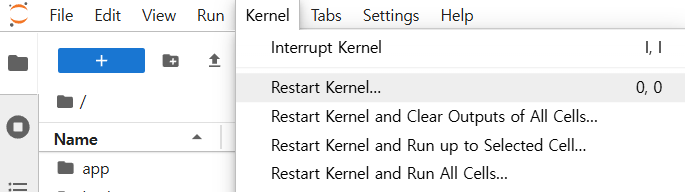

### 설치하기
- 해당 내용은 Unsloth 공식 Document 내용을 참고하였습니다.
- https://unsloth.ai/docs/get-started/install/pip-install

In [ ]:
# Colab에서는 진행하지 말것!!!
# 쥬피터랩에서 실행하기!!
!curl -fsSL https://unsloth.ai/install.sh | sh

In [1]:
%%capture
# Colab에서 설치 진행
!pip install unsloth

### 모델준비
- Qwen3-VL 4bit 양자화로 로딩
- 즉, 이번에도 QLoRA로 파인튜닝 할 예정입니다.

In [2]:
# 2분 정도 소요됩니다.
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen3-VL-8B-Instruct-unsloth-bnb-4bit",
    load_in_4bit = True,
    max_seq_length = 512,
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.3.18: Fast Qwen3_Vl patching. Transformers: 5.3.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/213 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/817 [00:00<?, ?B/s]

### LoRA 어댑터

In [3]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True, # False if not finetuning vision layers
    finetune_language_layers   = True, # False if not finetuning language layers
    finetune_attention_modules = True, # False if not finetuning attention layers
    finetune_mlp_modules       = True, # False if not finetuning MLP layers

    r = 16,           # The larger, the higher the accuracy, but might overfit
    lora_alpha = 16,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
    # target_modules = "all-linear", # Optional now! Can specify a list if needed
)

### 포켓몬 데이터 준비
- 영어이름, 속성, 소개 데이터

In [4]:
from datasets import load_dataset
dataset = load_dataset("tungdop2/pokemon", split = "train")

README.md:   0%|          | 0.00/794 [00:00<?, ?B/s]

data/train-00000-of-00001-5e017125a702cf(…):   0%|          | 0.00/163M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1271 [00:00<?, ? examples/s]

### 데이터 출력해보기

- 아르세우스(id=36) : 전설의 포켓몬. (포켓몬계의 단군 할아버지)

In [5]:
dataset

Dataset({
    features: ['image', 'name', 'type_1', 'type_2', 'caption'],
    num_rows: 1271
})

arceus
normal
None
a white and gold creature with a long tail and a green gem on its head.


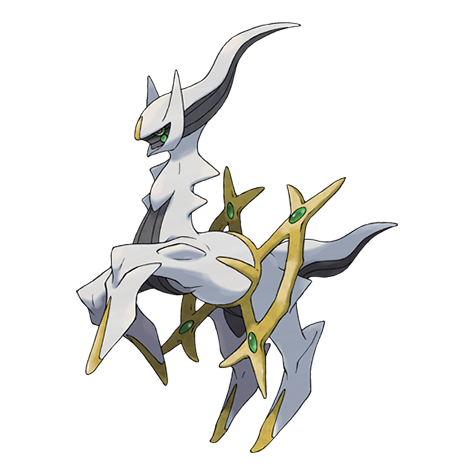

In [10]:
id = 36
print(dataset[id]["name"])
print(dataset[id]["type_1"])
print(dataset[id]["type_2"])
print(dataset[id]["caption"])
dataset[id]["image"]

### 모델이 원하는 입력 데이터 포맷

In [11]:
instruction = "이 포켓몬의 이름과 속성들을 말해줘, 한줄 요약"

def convert_to_conversation(sample):
    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": instruction},
                {"type": "image", "image": sample["image"]}
            ]
        },
        {
            "role": "assistant",
            "content": [
                {"type": "text",
                 "text": f"그의 이름은 {sample['name']} 이고, {sample['type_1']} / {sample.get('type_2', '')} 속성이지".strip()}
            ]
        }
    ]
    return {"messages": conversation}

In [12]:
converted_dataset = [convert_to_conversation(sample) for sample in dataset]

### 변경 완료된 포맷 확인

In [13]:
converted_dataset[id]

{'messages': [{'role': 'user',
   'content': [{'type': 'text', 'text': '이 포켓몬의 이름과 속성들을 말해줘, 한줄 요약'},
    {'type': 'image',
     'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=475x475>}]},
  {'role': 'assistant',
   'content': [{'type': 'text',
     'text': '그의 이름은 arceus 이고, normal / None 속성이지'}]}]}

### 파인튜닝 하기전에, 한번 확인해보기

- 모델이 상상해서 대답합니다.

In [14]:
FastVisionModel.for_inference(model) # Enable for inference!

image = dataset[id]["image"]
instruction = "이 포켓몬의 이름과 속성들을 말해줘, 한줄 요약"

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

이 포켓몬은 **하루카(ハルカ, Alola) 지역의 ** **알로라 라이즈** **이지만, 정확히는** **디아나(ディアナ, Dialga)** **가 아닙니다.**

> **정답:** **디아나(Dialga)**  
> **속성:** **드래곤 + 스릴드**  
> **한줄 요약:** **"시간의 왕"으로 불리는, 시간을 통제하는 드래곤 포켓몬.**

---

**※ 설명:**

사진에서 보이는


### 학습 세팅

In [15]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

FastVisionModel.for_training(model) # Enable for training!

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer), # Must use!
    train_dataset = converted_dataset,
    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 20,
        # num_train_epochs = 1, # Set this instead of max_steps for full training runs
        learning_rate = 2e-4,
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",     # For Weights and Biases

        # You MUST put the below items for vision finetuning:
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 2048,
    ),
)

Unsloth: Model does not have a default image size - using 512


In [16]:
trainer_stats = trainer.train()  # 3분 가량 소요됩니다.

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,271 | Num Epochs = 1 | Total steps = 20
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 51,346,944 of 8,818,470,640 (0.58% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,4.975029
2,4.924409
3,4.654915
4,4.447797
5,4.003230
6,3.329894
7,2.568513
8,2.276885
9,1.758376
10,1.678242


### 추론해보기

- 결과 : 학습된 형태의 대답할 확률은 높지만, 정확한 포켓몬 속성으로 대답할 확률은 낮은 편입니다.
- 지금보다 더 좋은 성능을 내기위해서는 step 수, 학습률 조율, 데이터 증강을하면 잘 됩니다.

=======정답 Label=========
arceus
normal
None
a white and gold creature with a long tail and a green gem on its head.
=======추론 시작==========
그의 이름은 Arceus  이고  Psychic/??? 속성이지


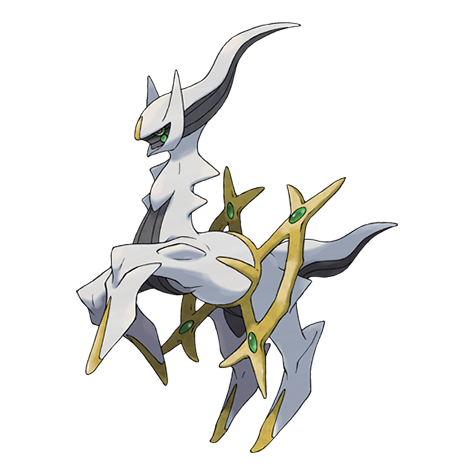

In [17]:
FastVisionModel.for_inference(model) # Enable for inference!

# 정답 Label
print('=======정답 Label=========')
print(dataset[id]["name"])
print(dataset[id]["type_1"])
print(dataset[id]["type_2"])
print(dataset[id]["caption"])


print('=======추론 시작==========')
# 여기서 부터 추론 시작
image = dataset[id]["image"]
instruction = "이 포켓몬의 이름과 속성들을 말해줘, 한줄 요약"

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True, skip_special_tokens=True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

dataset[id]["image"]

# 8. 끝으로

  - LoRA / QLoRA를 이해하고, Unsloth Library를 이용하여 추론과 파인튜닝을 했습니다.
  - 멀티모달 모델도 위와 같은 방법으로 추론, 파인튜닝을 할 수 있습니다.
    - 필요시 공식 Document가 굉장히 잘 나와있으니 참고하세요.
  - 파인튜닝은 많은 실험을 통해 좋은 결과를 얻을 수 있습니다.
    - 하이퍼파라미터 값을 무엇으로 할지,
    - 데이터셋이 부족한지, 퀄리티가 낮은지 고민하고,
    - 코드가 잘못된 부분이 있는지 고민하고,
    - 잘 될때까지 고민해야되는 것이 파인튜닝입니다.
  
<br/>

### Basic 자료 (강사님 자료)
- AI를 처음 공부하는 분들을 위해 만들어져있습니다.
- 기본 내용을 모두 이해해야합니다!

### 실습 / 과제 자료 (업스테이지 자료)
- AI를 공부해본 경험자 위주로 만들어져있습니다.
- 퍼즐조각을 모은다는 생각으로 공부해주세요!. **GPT의 도움을 적극적으로 받아주세요.**

### 교수님 강의
- 국내 최고의 AI 교수님들의 강의가 시작됩니다.
- 최대한 내용을 이해해봅시다.
  